# Python Code
For this task we can easily use a `jupyter` notebook, to easily visualize the data and adjust the in-slips hookload threshold. The first step is to import the required libraries, to help us load, filter nad plot the data:
- To start with we will need a library to handle the data, we use `pandas` which is well suited for tabular data.
- We combine `pandas` with `numpy` for greater flexibility to filter and process the data.
- To plot the data we use `matplotlib`, which is easily customizable and adjustable. To add interactive features, we use `ipywidgets`, which will help insert slider widgets to adjust the threshold value and time range.

In [1]:
import pandas as pd # Load and handle data
import numpy as np  # Process data
import matplotlib.pyplot as plt# Plot and visualize data
# import ipywidgets as widgets  # Interactive widgets
# from IPython.core.pylabtools import figsize
# from ipywidgets import interact # Function to update plot based on widgets values

For demonstration we will use the drilling data hosted in this blog's GitHub. We can call the data directly from the web link, using python's `requests` -- otherwise, if running the notebook on Colab we can directly use the `!wget` command in Linux.

Since the data is stored as a `json` file, the data is loaded into a `pandas` dataframe using the `read_json` function. The `pandas` `head()` command displays the top rows of the dataframe.

In [51]:
import requests

# Set drilling data url
data_url = 'https://raw.githubusercontent.com/SCallerio/MPDBlog/4a5c6d46d2873673681ac1fb3f32404be2187195/data/hookload-data.json'
# Fetch data from github
drilling_data = requests.get(data_url).text
# If running on Colab uncomment and use the following
# drilling_data = !wget data_url
# Load into a pandas dataframe
# drilling_data = r'C:\Users\sc67252\OneDrive - The University of Texas at Austin\Documents\MPDBlog\data\hookload-data.json'
data_df = pd.read_json(drilling_data)
# Display top rows
data_df.head()

C:\Users\sc67252\AppData\Local\Temp\ipykernel_32808\1605491322.py:11: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data_df = pd.read_json(drilling_data)


,time,signal,depth,mpd_pt5,mfia,mfoa
0,0.000000,158.9,9556.56,45.46,262,258
1,0.000556,158.6,9556.56,44.87,261,258
2,0.001111,158.6,9556.63,44.28,262,256
3,0.001667,158.1,9556.69,45.16,261,255
4,0.002222,158.2,9556.73,44.35,262,252


*<small>Table 1 - Example drilling data, including time (hours), hookload (klbf), hole depth (ft), MPD surface backpressure (psi), flow-in and flow-out (gpm)</small>*



The example data contains 24 hours of MPD drilling data, with the following columns:
 - time: reference elapsed time, expressed in hours
 - signal: hookload signal, expressed in klbf
 - depth: hole depth signal, expressed in feet (ft)
 - mpd_pt5: MPD surface backpressure (SBP), expressed in psi
 - mfia: Measured flow-in, in gallons per minute (gpm)
 - mfoa: Measured flow-out, measured by the MPD coriolis flowmeter, in gallons per minute (gpm)

Using these 4 parameters we can build a connections dashboard which uses hole depth as the main reference, and displays the connection time in minutes, and main statistics based on the SBP values during the in-slips period.

| Connection Depth (ft) | In-Slips Time (min) | Mean SBP | SBP Std. Dev |
| --------------------- | ------------------- | -------- | ------------ |
| 10,000                | 5                   | 500      | 25           |

*<small>Table 2 - Example connection table, showing connection data by depth including in-slips time, and mean and standard deviation for the MPD SBP</small>*

We will first visualize the data, plotting only the data between 3 to 6 hours where the first connection happens. Using a logical filter based on the 'time' column values, we set the time_mask variable to filter the first 2 hours in the dataset.

In [9]:
# Set time_mask to filter data between 3 to 6 hours,
# using a logical filter based on the 'time' column values
time_mask = (data_df['time'] > 3) & (data_df['time'] < 6) # hours
# Set plot data using the time mask filter
plot_data = data_df[time_mask]

### Matplotlib Initial Configuration
Set `tableau-colorblind10` as the default color schema. This standardizes the plot colors, and also ensures visualization for color-blind cases. We also import the `FuncFormatter` function, to show the depth axis using a comma delimiter for thousands (e.g. depth axis in plot is 9,000 ft, instead of 9000 ft). This funciton is used within the defined `format_thousands` function, which was defined for the `yaxis` of the input `ax`.

In [10]:
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter

# Set tableau-colorblind10 as the default color schema
# This standardizes the plot colors, and also ensures
# visualization for color-blind cases
style.use('tableau-colorblind10')
# Define colors variable, based on pre-defined color scheme
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Define plots font style as Arial, set font size
custom_font_properties = {
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
}
plt.rcParams.update(custom_font_properties)

# Define formater function for depth axis
def format_thousands(ax):
    ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    return

We will plot the 3 parameters using 3 subplots, divided into 3 rows in a single column (3 x 1 figure). The code below defines the first track, assigned to the `depth` parameter (i.e., hole depth).

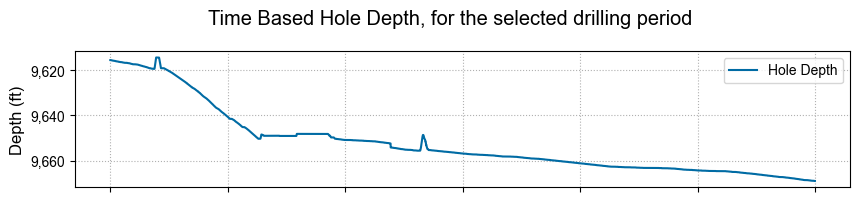

In [11]:
# Define figure parameter, set size
fig = plt.figure(figsize=(10, 6))
# Set plot title
plt.suptitle("Time Based Hole Depth, for the selected drilling period", y=0.95)
# Define Track #1, Hole Depth track
ax1 = plt.subplot(3,1,1)
ax1.plot(plot_data['time'],
         plot_data['depth'],
         label='Hole Depth',
         color = colors[0])
# Invert yaxis
ax1.invert_yaxis()
# Set thousands separator
format_thousands(ax1)
# Set y-axis label, remove x-axis tick-labels
ax1.set_ylabel('Depth (ft)')
ax1.set_xticklabels([])
# Display legend
ax1.legend(loc='upper right')
# Set dotted grid
ax1.grid(True, linestyle = 'dotted')
plt.show()

*<small>Fig. 1 - Hole depth versus time, for the selected drilling period</small>*

Since the commands for the three tracks are pretty similar, we define the function `plot_track` to plot each track, and then re-use it for every track updating the input parameters.

In [ ]:
def plot_track(rows, cols, i_plot, parameter, plot_data):
    """
    Plots plot_data[parameter], in subplots based on rows x cols configuration.
    The 'flow' parameter is a special case: it overlays Flow In (mfia) and
    Flow Out (mfoa) on the same track instead of a single column.
    :param rows: subplots number of rows (rows x cols figure)
    :param cols: subplots number of columns (rows x cols figure)
    :param i_plot: subplot number (less or equal to rows)
    :param parameter: track parameter
    :param plot_data: input data
    :return: matplotlib plot
    """
    # Define labels dictionary
    labels_dic = {
        'depth':'Hole Depth',
        'signal':'Hookload',
        'mpd_pt5':'SBP',
        'mfia':'Flow-In',
        'mfoa':'Flow-Out'
    }
    # Define ylabels dictionary
    ylabels_dic = {
        'depth':'Hole Depth (ft)',
        'signal':'Hookload (klbf)',
        'mpd_pt5':'SBP (psi)',
        'mfia':'Flow Rate (gpm)',
        'mfoa':'Flow Rate (gpm)'
    }
    linestyle_dic = {
        'depth':'-',
        'signal':'-',
        'mpd_pt5':'-',
        'mfia':'-',
        'mfoa':'--'
    }
    # Define Track #1, Hole Depth track
    ax = plt.subplot(rows, cols, i_plot)
    if isinstance(parameter, list):
        for i, p in enumerate(parameter):
            ax.plot(plot_data['time'],
                     plot_data[p],
                     label=labels_dic[p],
                     color = colors[i_plot-i-1],
                     linestyle = linestyle_dic[p])
            parameter = p # Set parameter to last value in list for y-axis label
        else:
            ax.plot(plot_data['time'],
                    plot_data[parameter],
                    label=labels_dic[parameter],
                    color = colors[i_plot-1])
        if parameter == 'depth':
            # Invert yaxis
            ax.invert_yaxis()

    # Set thousands separator
    format_thousands(ax)
    # Set y-axis label, remove x-axis tick-labels
    ax.set_ylabel(ylabels_dic[parameter])
    if i_plot < rows:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (hours)')
    # Display legend
    ax.legend(loc='upper right')
    # Set dotted grid
    ax.grid(True, linestyle = 'dotted')
    return

Then using the `plot_track` function, we plot the 3 parameters, showing the first connection in the dataset (Fig. 2). As observed, when the connection happens, the hookload reflects the characteristic U-shape with a block weight between 50 to 60 klbf.

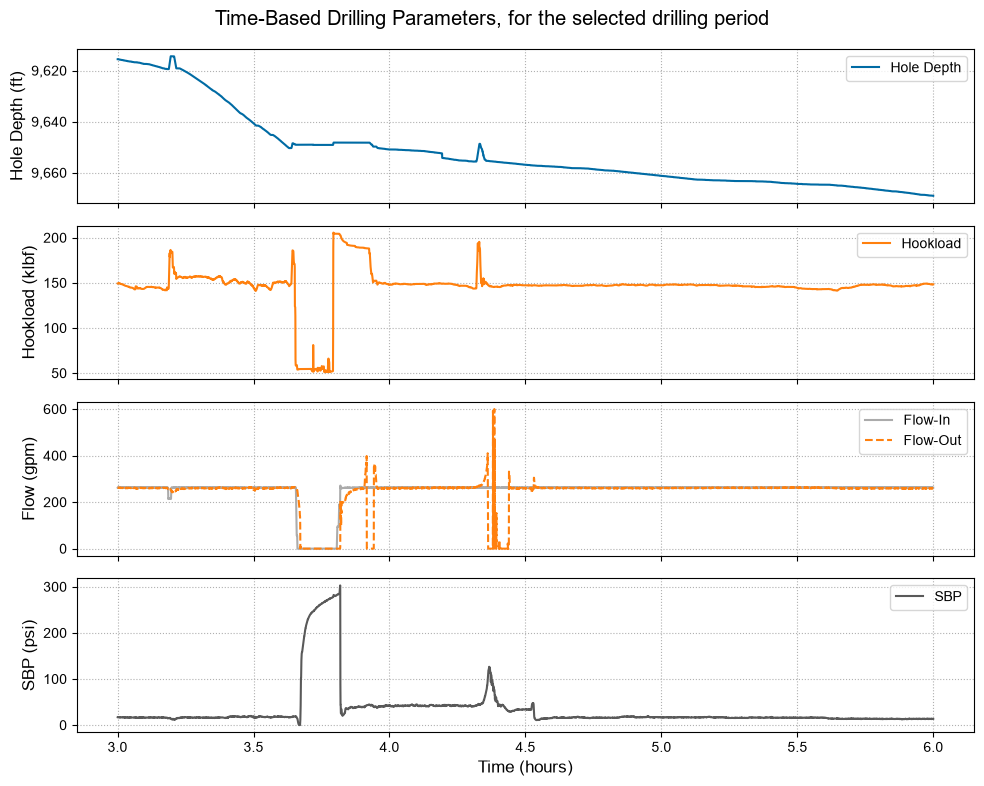

In [53]:
# Define subplots rows and columns
rows = 4
cols = 1
# Define figure parameter, set size
fig = plt.figure(figsize=(10, 8))
# Set plot title
plt.suptitle('Time-Based Drilling Parameters, for the selected drilling period', y=0.98)
# Define Track #1, Hole Depth track
plot_track(rows, cols, i_plot = 1, parameter = 'depth', plot_data = plot_data)
# Define Track #2, Hookload track
plot_track(rows, cols, i_plot = 2, parameter = 'signal', plot_data = plot_data)
# Define Track #3, Flow track
plot_track(rows, cols, i_plot = 3, parameter = ['mfia', 'mfoa'], plot_data = plot_data)
# Define Track #4, SBP track
plot_track(rows, cols, i_plot = 4, parameter = 'mpd_pt5', plot_data = plot_data)
plt.tight_layout()
plt.show()

*<small>Fig. 2 - Drilling parameters, showing the first MPD connection happening between 3.5 to 4 hours, where the top track shows the hole depth, the second track shows the hookload, the third track the Flow In/Out, and the bottom track the SBP. **The hookload shows the characteristic U-shaped signal during the connection, with a reference block weight ~50 to 60 klbf, and flow in/out both drop to near-zero as circulation stops for the connection**</small>*

#### Dark-Theme Option
We can easily switch to a dark-themed plot changing the matplotlib style to `dark_background`, as shown on the next cell.

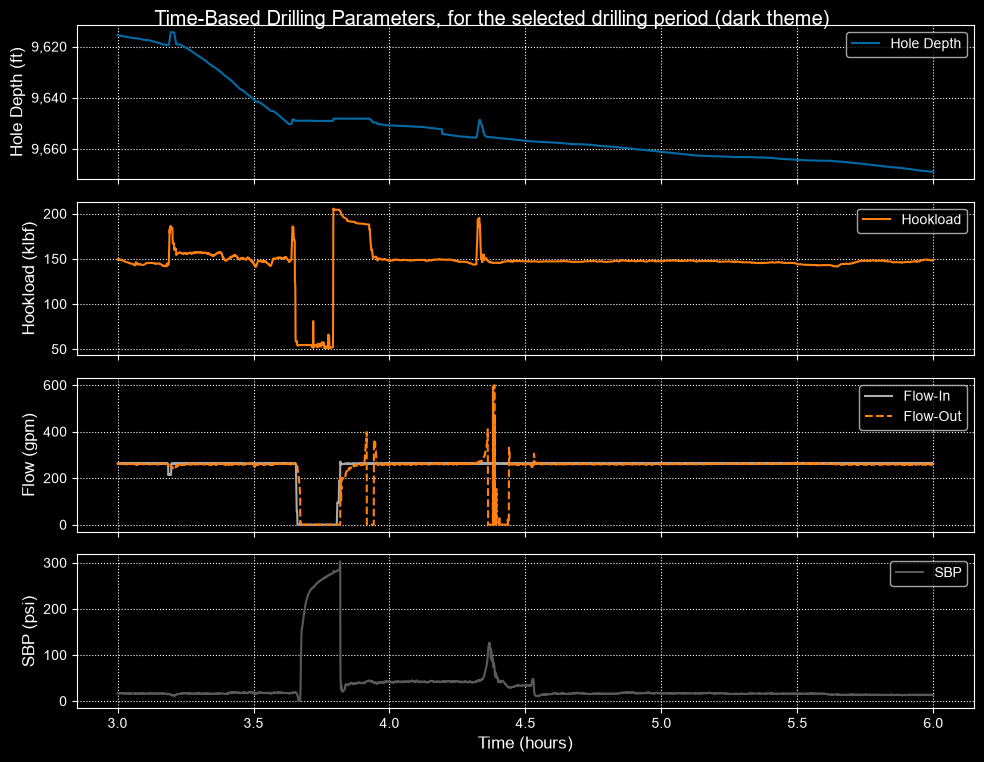

In [55]:
# Set matplotlib color scheme for dark themed plots
plt.style.use('dark_background')
style.use('tableau-colorblind10')
# Define figure parameter, set size
fig = plt.figure(figsize=(10, 8))
# Set plot title
plt.suptitle('Time-Based Drilling Parameters, for the selected drilling period (dark theme)', y=0.95)
# Define Track #1, Hole Depth track
plot_track(rows, cols, i_plot = 1, parameter = 'depth', plot_data = plot_data)
# Define Track #2, Hookload track
plot_track(rows, cols, i_plot = 2, parameter = 'signal', plot_data = plot_data)
# Define Track #3, Flow track
plot_track(rows, cols, i_plot = 3, parameter = ['mfia', 'mfoa'], plot_data = plot_data)
# Define Track #4, SBP track
plot_track(rows, cols, i_plot = 4, parameter = 'mpd_pt5', plot_data = plot_data)
plt.tight_layout()
plt.show()

*<small>Fig. 3 - Same drilling parameters as Fig. 2, including the Flow In/Out track, rendered using the dark theme.</small>*

To revert to the light theme (white background figures) we call the following code:

In [60]:
# Revert to light theme style (white background)
plt.style.use('default')
plt.rcParams.update(custom_font_properties)
style.use('tableau-colorblind10')

# In-Slips Hookload Selection

As observed by Fig. 2 and 3, **the hookload signal shows a characteristic U-shaped response during the connection, with a reference block weight ~50 to 60 klbf, signaling that the drillstring is set 'in-slips' to add a new drilling stand.**

Based on this, we can establish a simple logic to filter out the 'in-slips' and 'out-slips' periods (as detailed below), to focus on the connections parameters happening during the 'in-slips' periods. This is done, as shown on Fig. 4, by setting a hookload threshold that intersects the U-shaped response. 

```python
if hookload < hookload_threshold:
	in_slips = True
else:
	in_slips = False
```

For this case, the threshold was set to 80 klbf, highlighting the 'in-slips' values in orange, and 'out-slips' in blue.

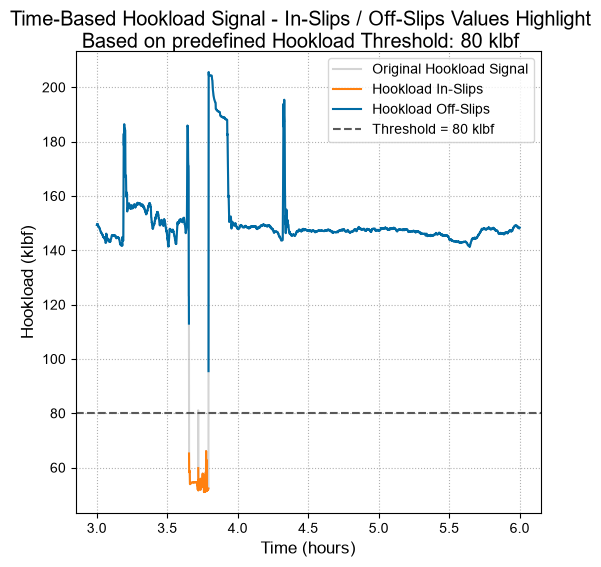

In [61]:
# Plot 1: Signal vs. Time
# plot_track(1, 1, 1, 'signal', plot_data)
time = plot_data['time']
signal = plot_data['signal']
threshold = 80
# Define figure parameter, set size
fig = plt.figure(figsize=(6, 6))
# Set plot title
plt.suptitle(f'Time-Based Hookload Signal - In-Slips / Off-Slips Values Highlight\nBased on predefined Hookload Threshold: {threshold:.0f} klbf', y=0.95)
ax = plt.subplot(111)
ax.plot(time,
        signal,
        label='Original Hookload Signal',
        color=colors[2], alpha=0.5)
ax.plot(time,
        np.where(signal < threshold, signal, np.nan),
        label='Hookload In-Slips',
        color=colors[1])
ax.plot(time,
        np.where(signal >= threshold, signal, np.nan),
        label='Hookload Off-Slips',
        color=colors[0])
ax.axhline(y=threshold,
           color=colors[3],
           linestyle='--',
           label=f'Threshold = {threshold:.0f} klbf')
# Set x and y-axis label
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Hookload (klbf)')
plt.grid(True, linestyle='dotted')
plt.legend()
plt.show()

*<small>Fig. 4 - Hookload signal with in-slips (below threshold, orange) and off-slips (above threshold, blue) highlighted, using a fixed threshold of 80 klbf.</small>*

## Dynamic Threshold Selection

To aid the selection and adjustment of the appropiate hookload threshold, we define a slider widget to dynamically update and plot the hookload values, using the `ipywidgets` library ([readthedocs ipywidgets widget list](https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html)).

In [62]:
import ipywidgets as widgets
from ipywidgets import interact

# Create the interactive slider widget
# Set slider values range from loaded drilling data
min_val = data_df['signal'].min()
max_val = data_df['signal'].max()
step_val = (max_val - min_val) / 100
# Define the threshold slider as a Float Slider
threshold_slider = widgets.FloatSlider(
    min=min_val,
    max=max_val,
    step=step_val,
    value=(min_val + max_val) / 2,
    description='Threshold (klbf)'
)
# Display the defined threshold_slider
display(threshold_slider)

FloatSlider(value=131.65, description='Threshold (klbf)', max=213.6, min=49.7, step=1.6389999999999998)

 The slider can be moved to the right/left to update the hookload threshold value. The defined threshold value can be extracted by calling the `value` parameter.

In [63]:
print(f"Selected threshold value: {threshold_slider.value: .2f} klbf")

Selected threshold value:  131.65 klbf


In [64]:
# import ipywidgets as widgets
# from ipywidgets import interact

# Function to create the interactive plot
def plot_interactive_threshold(threshold, signal, time):
    """
    Generates an interactive plot with a movable threshold line.

    Args:
        threshold (float): The value for the threshold line.
    """
    # plt.rcParams['font.family'] = 'arial'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Signal vs. Time
    ax1.plot(time, signal, label='Original Hookload Signal', color=colors[2], alpha=0.5)
    ax1.plot(time, np.where(signal < threshold, signal, np.nan), label='Hookload In-Slips', color=colors[1])
    ax1.plot(time, np.where(signal >= threshold, signal, np.nan), label='Hookload Off-Slips', color=colors[0])
    ax1.axhline(y=threshold, color=colors[3], linestyle='--', label=f'Threshold = {threshold:.2f} klbf')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Hookload Value (klbf)')
    ax1.set_title('Hookload vs. Time')
    ax1.legend()
    ax1.grid(True)
    fig.autofmt_xdate()

    # Plot 2: Signal Distribution
    ax2.hist(signal, bins=10, orientation='horizontal', color=colors[0], label='Distribution')
    ax2.axhline(y=threshold, color=colors[1], linestyle='--', label=f'Threshold = {threshold:.2f} klbf')
    ax2.set_xlabel('Frequency')
    ax2.set_ylabel('Hookload Value (klbf)')
    ax2.set_title('Hookload Distribution')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    output_threshold = widgets.Output()
    with output_threshold:
        output_threshold.clear_output(wait=True)
        print(f'Selected Threshold: {threshold:.2f} klbf')
    display(output_threshold)
    return

In [65]:
# Create the interactive slider widget
min_val = plot_data['signal'].min()
max_val = plot_data['signal'].max()
step_val = (max_val - min_val) / 100

threshold_slider = widgets.FloatSlider(
    min=min_val,
    max=max_val,
    step=step_val,
    value=(min_val + max_val) / 2,
    description='Threshold'
)

interact(plot_interactive_threshold,
         threshold=threshold_slider
         , signal= widgets.fixed(plot_data['signal'].values)
         , time=widgets.fixed(plot_data['time'].values))

# 3. Create an output area to display the live value
live_output_display = widgets.Output()

# 4. Define a function to handle the slider's value change
def on_threshold_change(change):
    """
    This function is called whenever the slider value changes.
    It updates the live display with the new value.
    """
    with live_output_display:
        live_output_display.clear_output(wait=True)
        print(f"Current Threshold Value: {change.new}")

# 5. "Observe" the slider's value. This links the slider to the handler function.
threshold_slider.observe(on_threshold_change, names='value')

interactive(children=(FloatSlider(value=128.3, description='Threshold', max=205.6, min=51.0, step=1.546), Outp…

*<small>Fig. 5 - Interactive version of Fig. 4: drag the slider to adjust the hookload threshold and see the in-slips/off-slips split (left) and hookload distribution (right) update live. The hookload distribution shows 3 clearly distinguished clusters, where the lower one corresponds to the in-slips values.</small>*

## Summarize Connections Statistics
Using the previously defined logic, we can now filter the 'in-slips' values to focus on the MPD connections values. 

The table below shows the connections SBP statistics by depth for the selected drilling period.

In [66]:
# Retrieve the current value of the threshold slider
hkld_threshold = threshold_slider.value
# Filter the in-slips data based on the threshold value
mask_hkld = data_df['signal'] < hkld_threshold
filtered_df = data_df[mask_hkld]
# Calculate SBP statistics by depth, for the filtered in-slips data (MPD connections)
sbp_by_depth_stats = filtered_df.groupby(filtered_df['depth'].astype(int))['mpd_pt5'].describe().reset_index()
display(sbp_by_depth_stats)

,depth,count,mean,std,min,25%,50%,75%,max
0,9648,5.0,70.322000,115.984045,18.03,18.4000,18.69,18.6900,277.80
1,9649,249.0,210.306466,87.887408,0.00,201.7800,248.38,265.9500,277.66
2,9743,524.0,204.269084,43.747885,0.00,186.7400,216.46,235.6325,250.63
3,9839,291.0,102.791478,60.284417,0.00,45.7450,129.19,152.1350,168.55
4,9933,192.0,215.711875,25.499580,131.93,212.0825,224.00,231.0700,236.48


*<small>Table 3 - SBP statistics grouped by connection depth (in-slips samples only, i.e. hookload below the selected threshold), computed with pandas' `.describe()`. The table shows the SBP mean, standard deviation, minimum and maximum values, besides the normal distribution P25, P50 and P75 values.</small>*

We can also filter the time per connection, to evaluate the time in minutes per connection.

In [67]:
# Calculate time difference by depth for the filtered in-slips data
time_by_depth = filtered_df.groupby(filtered_df['depth'].astype(int))['time'].agg(['min', 'max']).reset_index()
# Calculate time difference in minutes
time_by_depth['time_diff_min'] = (time_by_depth['max'] - time_by_depth['min'])*60
display(time_by_depth)

,depth,min,max,time_diff_min
0,9648,3.652222,3.792778,8.433333
1,9649,3.654444,3.792222,8.266667
2,9743,12.699444,12.990000,17.433333
3,9839,17.783333,17.944444,9.666667
4,9933,22.765000,22.871111,6.366667


*<small>Table 4 - Elapsed time range (min/max, hours) and connection duration (minutes) per connection depth.</small>*

We can now merge table

In [68]:
# Merge SBP statistics and time difference by depth into a single dataframe
cnx_stats = pd.merge(sbp_by_depth_stats, time_by_depth[['depth', 'time_diff_min']], on='depth')
# Select and round the relevant columns, then rename them for clarity
cnx_stats = cnx_stats[['depth', 'time_diff_min', 'mean', 'std', 'max']].round(1)
cnx_stats.rename(columns = {
    'depth':'Connection Depth',
    'time_diff_min': 'Connection Time (min)',
    'mean': 'Mean SBP (psi)',
    'std': 'Std. Dev. SBP (psi)',
    'max': 'Max. SBP (psi)'
}, inplace=True)
display(cnx_stats)

,Connection Depth,Connection Time (min),Mean SBP (psi),Std. Dev. SBP (psi),Max. SBP (psi)
0,9648,8.4,70.3,116.0,277.8
1,9649,8.3,210.3,87.9,277.7
2,9743,17.4,204.3,43.7,250.6
3,9839,9.7,102.8,60.3,168.6
4,9933,6.4,215.7,25.5,236.5


*<small>Table 5 - Final connections summary: connection depth, connection time (min), and SBP mean/std. dev./max (psi) per connection, merged from Tables 1 and 2.</small>*

## Python Equivalent of the Web Dashboard's Stats Computation

The interactive version of this dashboard (see the blog post) computes these same per-connection statistics client-side in JavaScript (`hookload_threshold_computeStats.js`). The cells below are a direct Python translation of that logic — grouping in-slips samples by connection depth, then computing duration and SBP statistics per group, plus the two supporting plots (SBP vs. elapsed time, and an SBP boxplot) that the JS version renders.

In [69]:
def group_inslips_by_depth(data_df, threshold):
    """
    Filters to in-slips samples (signal < threshold) and buckets their
    elapsed time and SBP (mpd_pt5) by hole depth, rounded to the nearest
    foot. Mirrors the filter + grouping block at the top of
    hookload_threshold_computeStats.js's computeStats().
    """
    inslips = data_df[data_df['signal'] < threshold]
    groups = {}
    for depth_ft, time_hr, sbp in zip(inslips['depth'], inslips['time'], inslips['mpd_pt5']):
        # Round-to-nearest-foot bucketing, matching the JS's Math.round(depth)
        # (note this differs from the .astype(int) truncation used earlier
        # in this notebook, which rounds toward zero instead)
        key = int(round(depth_ft))
        bucket = groups.setdefault(key, {'time': [], 'mpd_pt5': []})
        bucket['time'].append(time_hr)
        bucket['mpd_pt5'].append(sbp)
    return groups

In [70]:
def compute_depth_stats(groups):
    """
    Computes in-slips duration (minutes) and SBP mean/std/min/25%/50%/75%/max
    for each connection depth bucket produced by group_inslips_by_depth().

    Uses the same nearest-rank (floor-index) quantile method as the JS
    version, e.g. sortedVals[Math.floor(n * 0.25)] -- this differs from the
    linear-interpolation quantiles pandas' .describe() uses in the
    sbp_by_depth_stats cell above, so the numbers won't match exactly.
    """
    rows = []
    for depth_ft in sorted(groups):
        times = np.asarray(groups[depth_ft]['time'], dtype=float)
        values = np.asarray(groups[depth_ft]['mpd_pt5'], dtype=float)
        if values.size == 0:
            continue

        # Duration in minutes needs at least two time samples
        duration_min = 0.0
        if times.size >= 2:
            duration_min = round((times.max() - times.min()) * 60 * 10) / 10

        sorted_vals = np.sort(values)
        n = sorted_vals.size

        def floor_quantile(q):
            # Nearest-rank quantile (floor index), matching the JS:
            # sortedVals[Math.floor(n * q)]
            return sorted_vals[int(np.floor(n * q))]

        rows.append({
            'Connection Depth (ft)': depth_ft,
            'Connection Time (min)': duration_min,
            'Mean SBP (psi)': round(values.mean()),
            'Std. Dev. SBP (psi)': round(values.std()),  # population std (ddof=0), matches the JS
            'Min SBP (psi)': round(sorted_vals[0]),
            '25% SBP (psi)': round(floor_quantile(0.25)),
            '50% SBP (psi)': round(floor_quantile(0.50)),
            '75% SBP (psi)': round(floor_quantile(0.75)),
            'Max SBP (psi)': round(sorted_vals[-1]),
        })
    return pd.DataFrame(rows)

In [71]:
def plot_sbp_by_depth_timeseries(groups, ax=None):
    """
    Plots SBP vs. elapsed time for each connection depth, with elapsed
    time shifted so each connection's first sample starts at t=0 and
    converted from hours to minutes. Mirrors renderSBPTimeSeries() from
    hookload_threshold_computeStats.js, reusing this notebook's
    tableau-colorblind10 color cycle instead of a hardcoded hex palette.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
    for i, depth_ft in enumerate(sorted(groups)):
        times = np.asarray(groups[depth_ft]['time'], dtype=float)
        values = np.asarray(groups[depth_ft]['mpd_pt5'], dtype=float)
        if times.size == 0:
            continue
        # Sort by time, then zero and convert to minutes
        order = np.argsort(times)
        elapsed_min = (times[order] - times[order][0]) * 60
        ax.plot(elapsed_min, values[order],
                label=f'SBP @ {depth_ft:,} ft MD',
                color=colors[i % len(colors)])
    ax.set_xlabel('Elapsed Time (min)')
    ax.set_ylabel('SBP (psi)')
    ax.set_title('SBP vs. Elapsed Time by Connection Depth')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='dotted')
    return ax

In [72]:
def plot_sbp_boxplots_by_depth(groups, ax=None):
    """
    Draws a boxplot of SBP values for each connection depth. Mirrors
    renderBoxplots() from hookload_threshold_computeStats.js, using this
    notebook's tableau-colorblind10 color cycle for each box.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    depths = sorted(groups)
    data = [np.asarray(groups[d]['mpd_pt5'], dtype=float) for d in depths]
    bp = ax.boxplot(data, tick_labels=[f'{d:,}' for d in depths], patch_artist=True)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[i % len(colors)])
    ax.set_xlabel('Connection Depth (ft)')
    ax.set_ylabel('SBP (psi)')
    ax.set_title('SBP Distribution by Connection Depth')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='dotted', axis='y')
    return ax

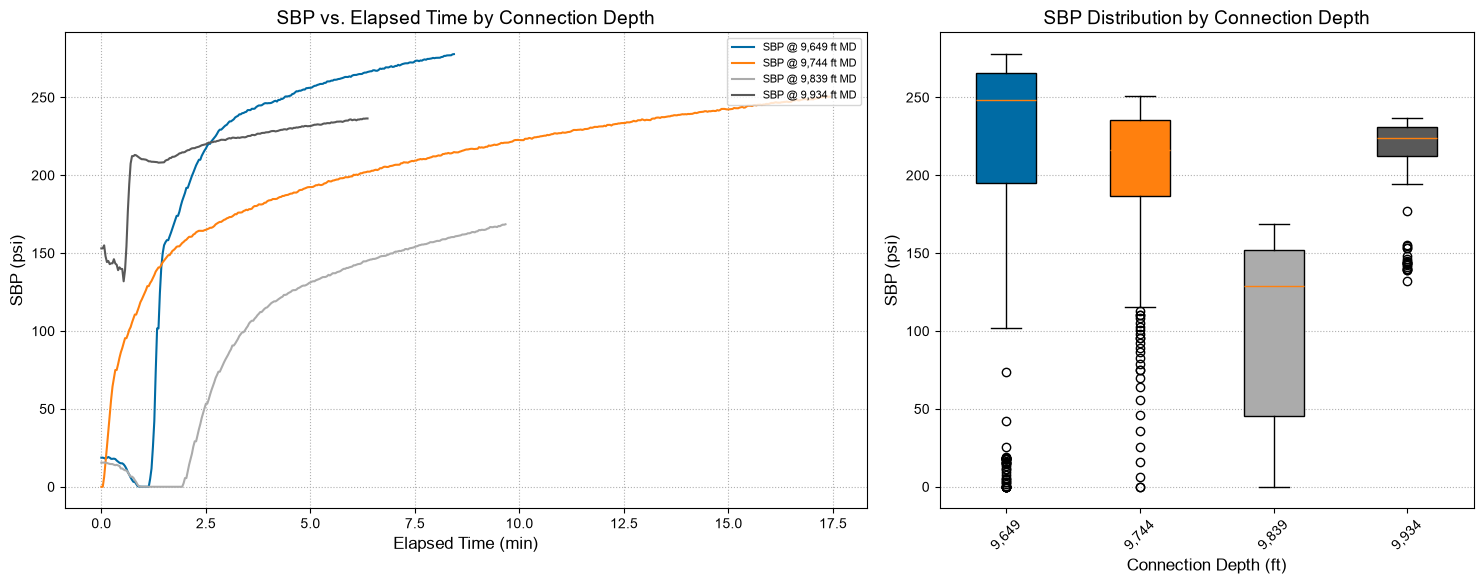

,Connection Depth (ft),Connection Time (min),Mean SBP (psi),Std. Dev. SBP (psi),Min SBP (psi),25% SBP (psi),50% SBP (psi),75% SBP (psi),Max SBP (psi)
0,9649,8.4,208,90,0,195,248,266,278
1,9744,17.4,204,44,0,187,217,236,251
2,9839,9.7,103,60,0,44,129,152,169
3,9934,6.4,216,25,132,212,224,231,236


In [73]:
# Re-run the JS dashboard's grouping + stats logic in Python, using the
# threshold already selected via the slider above (hkld_threshold)
groups = group_inslips_by_depth(data_df, hkld_threshold)
depth_stats = compute_depth_stats(groups)

fig, (ax_ts, ax_box) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 2]})
plot_sbp_by_depth_timeseries(groups, ax=ax_ts)
plot_sbp_boxplots_by_depth(groups, ax=ax_box)
plt.tight_layout()
plt.show()

depth_stats

*<small>Fig. 6 - Python translation of the web dashboard's per-depth SBP time series (left) and SBP distribution boxplot (right).</small>*

*<small>Table 4 - Per-depth connection stats computed the same way as the web dashboard's `computeStats()` (floor-index quantiles) — differs slightly from Tables 1 and 3 above, which use pandas' interpolated quantiles.</small>*